***Задание. Реализовать классификацию изображений на своем датасете.***

1. Выберите датасет для классификации изображений https://pytorch.org/vision/stable/datasets.html
2. Определите архитектуру нейросети и приведите ее описание (текстом или иным способом) в своей работе
3. Реализуйте выбранную архитектуру в виде класса
4. Обучите нейросеть 
5. Постройте на одном графике кривые изменения функции потерь на тесте и обучении
6. Постройте график изменения выбранной метрики качества на тесте
7. Сохраните в файл одно изображение из тестовой выборки
8. Сохраните обученную нейросеть в файл
9. Загрузите изображение из файла
10. Загрузите нейросеть
11. Выполните предсказание с помощью загруженной из файла нейросети и оцените его правильность

Был взять датасет CIFAR10.
The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images. 

| Метка | Описание       |
|-------|----------------|
| 0     | airplane       |
| 1     | automobile     |
| 2     | bird           |
| 3     | cat            |
| 4     | deer           |
| 5     | dog            |
| 6     | frog           |
| 7     | horse          |
| 8     | ship           |
| 9     | truck          |

In [1]:
import torch
import random
import numpy as np
import torchvision.datasets
import numpy as np
import matplotlib.pyplot as plt

random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed(0)
torch.backends.cudnn.deterministic = True

In [2]:

from torch.autograd import Variable
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torch.nn.functional as F
import numpy as np
import torch.utils.data as td
import random,time
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader


In [3]:
# num_epochs = 10
batch_size = 128
# test_batch_size = 64
# input_size = 3072

In [4]:
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                     std=[0.225, 0.225, 0.225])
cifar_train = datasets.CIFAR10('./', train=True, download=True, 
        transform=transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.RandomCrop(32, 4),
            transforms.ToTensor(),
            normalize,
        ]))
cifar_test = datasets.CIFAR10('./', train=False, 
        transform=transforms.Compose([transforms.ToTensor(), normalize]))
cifar_train_loader = torch.utils.data.DataLoader(cifar_train, batch_size=batch_size,
        shuffle=True, pin_memory=True)
cifar_test_loader = torch.utils.data.DataLoader(cifar_test, batch_size=batch_size,
        shuffle=False, pin_memory=True)

In [5]:
classes = ('plane', 'car', 'bird', 'cat', 'deer', 
           'dog', 'frog', 'horse', 'ship', 'truck')

In [6]:
# формируем датасеты для обучения, тестирования, целевые переменные
X_train = cifar_train_loader.dataset.data
y_train = cifar_train_loader.dataset.targets
X_test = cifar_test_loader.dataset.data  
y_test = cifar_test_loader.dataset.targets

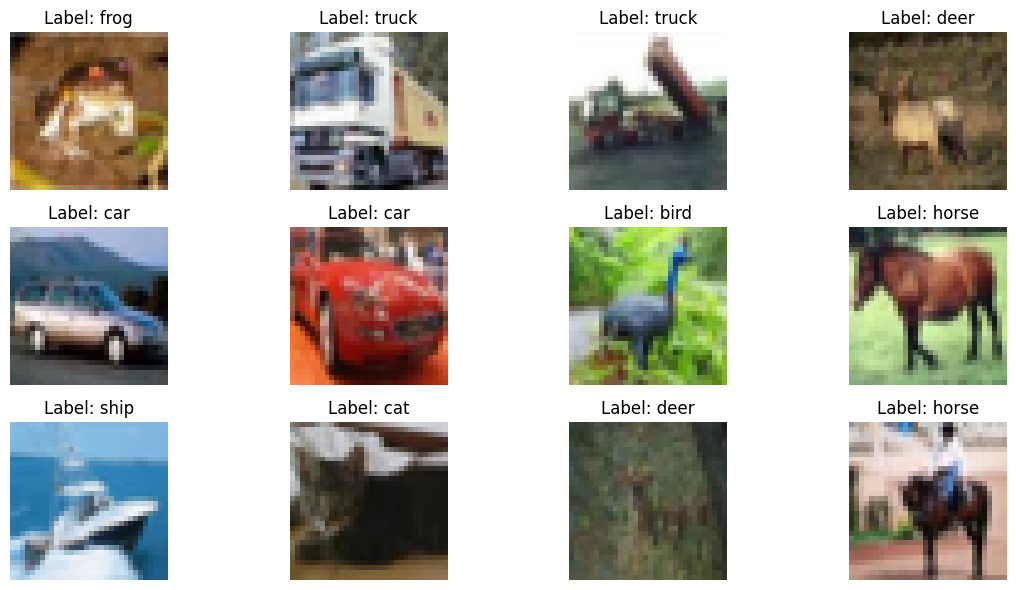

In [7]:
# посмотрим, что пришло

import numpy as np
import matplotlib.pyplot as plt

# посмотрим какие-то произвольные изображения из датасета
plt.figure(figsize=(12, 6))
for i in range(12):  # покажем 12 изображений
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_train[i])  # CIFAR-10 уже в правильном формате (32, 32, 3)
    plt.title(f'Label: {classes[y_train[i]]}')
    plt.axis('off')
plt.tight_layout()
plt.show()

In [8]:
len(y_train), len(y_test)

(50000, 10000)

In [9]:
type(X_train[10, :, :])

numpy.ndarray

In [10]:
X_train.shape

(50000, 32, 32, 3)

    MNIST: (N, 28, 28) → нужно unsqueeze(1) → (N, 1, 28, 28)

    CIFAR-10: (N, 32, 32, 3) → нужно permute(0, 3, 1, 2) → (N, 3, 32, 32)

In [11]:
# Сначала преобразуем numpy массивы в PyTorch тензоры
X_train_tensor = torch.from_numpy(X_train).float()
X_test_tensor = torch.from_numpy(X_test).float()

# Теперь меняем порядок осей для соответствия формату PyTorch (N, C, H, W)
X_train_tensor = X_train_tensor.permute(0, 3, 1, 2)
X_test_tensor = X_test_tensor.permute(0, 3, 1, 2)

y_train_tensor = torch.from_numpy(np.array(y_train)).long()
y_test_tensor = torch.from_numpy(np.array(y_test)).long()


print(f"Форма X_train_tensor после permute: {X_train_tensor.shape}")

Форма X_train_tensor после permute: torch.Size([50000, 3, 32, 32])


In [12]:
# y_train_tensor = torch.tensor(y_train)
# y_test_tensor = torch.tensor(y_test)

In [13]:
print(f"Форма y_train_tensor: {y_train_tensor.shape}")

# Пример доступа к одному изображению
print(f"Форма одного изображения: {X_train_tensor[0].shape}")
print(f"Диапазон значений пикселей: [{X_train_tensor[0].min():.3f}, {X_train_tensor[0].max():.3f}]")

Форма y_train_tensor: torch.Size([50000])
Форма одного изображения: torch.Size([3, 32, 32])
Диапазон значений пикселей: [0.000, 255.000]


In [14]:
X_train_tensor.shape

torch.Size([50000, 3, 32, 32])

Для дальнейшего использования, я выбрал стандартную архитектуру ResNet-18.

ResNet (Residual Neural Network) — это архитектура нейронных сетей, которая решает проблему исчезающего градиента и сложностей при обучении очень глубоких сетей. Основная идея ResNet — использование остаточных блоков с пропускными соединениями (skip connections), которые позволяют сигналу информации проходить через несколько слоев напрямую, минуя некоторые из них. Это упрощает оптимизацию и ускоряет обучение.

Принцип работы ResNet основан на формуле F(x)+xF(x)+x, где F(x)F(x) — результат работы слоя, а xx — входные данные.

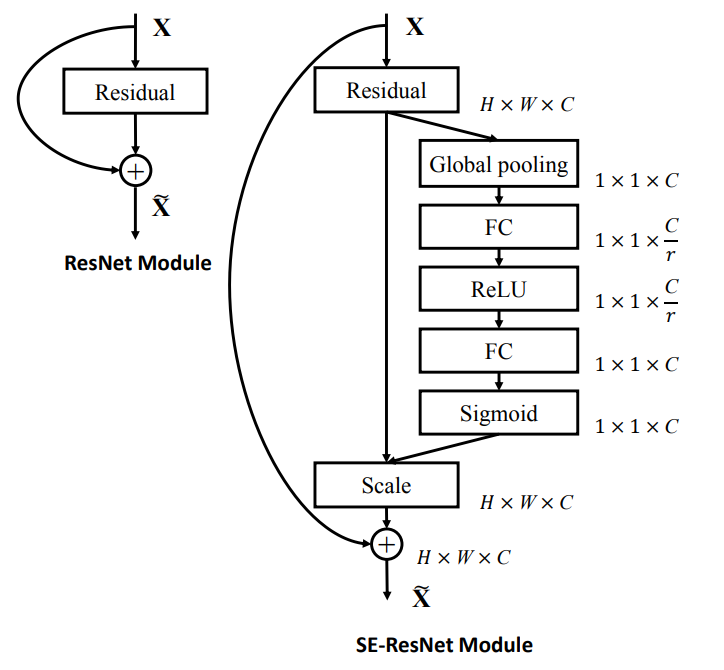

In [15]:
class BasicBlock(nn.Module):
    """Базовый блок для ResNet-18"""
    expansion = 1
    
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(
            in_channels, out_channels, 
            kernel_size=3, stride=stride, padding=1, bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(
            out_channels, out_channels, 
            kernel_size=3, stride=1, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample
        
    def forward(self, x):
        identity = x
        
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        
        out = self.conv2(out)
        out = self.bn2(out)
        
        if self.downsample is not None:
            identity = self.downsample(x)
            
        out += identity
        out = self.relu(out)
        
        return out



In [16]:
class ResNet18(nn.Module):
    """Реализация ResNet-18"""
    
    def __init__(self, num_classes=1000):
        super(ResNet18, self).__init__()
        
        self.in_channels = 64
        
        # Начальные слои
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        
        # Слои ResNet
        self.layer1 = self._make_layer(64, 64, 2, stride=1)
        self.layer2 = self._make_layer(64, 128, 2, stride=2)
        self.layer3 = self._make_layer(128, 256, 2, stride=2)
        self.layer4 = self._make_layer(256, 512, 2, stride=2)
        
        # Классификатор
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * BasicBlock.expansion, num_classes)
        
        # Инициализация весов
        self._initialize_weights()
        
    def _make_layer(self, in_channels, out_channels, blocks, stride):
        downsample = None
        
        # Если нужно изменить размерность (stride != 1 или каналы не совпадают)
        if stride != 1 or self.in_channels != out_channels * BasicBlock.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(
                    self.in_channels, 
                    out_channels * BasicBlock.expansion,
                    kernel_size=1, stride=stride, bias=False
                ),
                nn.BatchNorm2d(out_channels * BasicBlock.expansion),
            )
            
        layers = []
        layers.append(
            BasicBlock(self.in_channels, out_channels, stride, downsample)
        )
        self.in_channels = out_channels * BasicBlock.expansion
        
        for _ in range(1, blocks):
            layers.append(BasicBlock(self.in_channels, out_channels))
            
        return nn.Sequential(*layers)
    
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
                
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        
        return x


    


In [20]:
resnet = ResNet18()

In [21]:
# определяем, где будет обучаться наша СNN
# если есть граф процессор от Nvidia, то на нем. Если нет, то на cpu

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
#device = "cpu"

# отправляем туда нашу нейронку
resnet = resnet.to(device)

In [22]:
# в качестве функции потерь будем использовать CrossEntropyLoss()
loss = torch.nn.CrossEntropyLoss()

# в качестве оптимайзера, который будет вычислять градиенты и минимизировать функцию потерь, будем использовать Adam (Адаптивная оценка момента)
optimizer = torch.optim.Adam(resnet.parameters(), lr=1.0e-3)

In [23]:
# будем оптимизировать по 100 параметров одним комплектом (бачем)
# batch_size = 100

# чтобы посмотреть, как и что у нас тут менялось при оптимизации на тестовой выборке
test_accuracy_history = []
test_loss_history = []


train_loss_history = []

# не забываем отправить все выборки на устройство, на котором обучаем
# X_test = X_test.to(device)
# y_test = y_test.to(device)

X_test_tensor = X_test_tensor.to(device)
y_test_tensor = y_test_tensor.to(device)

for epoch in range(20):
    order = np.random.permutation(len(X_train_tensor))
    for start_index in range(0, len(X_train_tensor), batch_size):
        # обязательно обнуляем градиенты
        optimizer.zero_grad()

        # берем пачку параметров
        batch_indexes = order[start_index:start_index+batch_size]

        X_batch = X_train_tensor[batch_indexes].to(device)
        y_batch = y_train_tensor[batch_indexes].to(device)

        # делаем предсказание
        preds = resnet.forward(X_batch)

        # считаем лосс значение
        loss_value = loss(preds, y_batch)

        # берем градиенты
        loss_value.backward()

        # и пусть оптимайзер все оптимизирует
        optimizer.step()

    # смотрим, что он тут нам напредсказывал, не забывая вовремя отправлять на cpu
    train_loss_history.append(loss_value.data.cpu())

    test_preds = resnet.forward(X_test_tensor)
    test_loss_history.append(loss(test_preds, y_test_tensor).data.cpu())


    accuracy = (test_preds.argmax(dim=1) == y_test_tensor).float().mean().data.cpu()
    test_accuracy_history.append(accuracy)

    print(f"epoch{epoch} - accuracy test {accuracy} ")

epoch0 - accuracy test 0.6338000297546387 
epoch1 - accuracy test 0.6923999786376953 
epoch2 - accuracy test 0.7243000268936157 
epoch3 - accuracy test 0.7520999908447266 
epoch4 - accuracy test 0.7421000003814697 
epoch5 - accuracy test 0.7541999816894531 
epoch6 - accuracy test 0.7541000247001648 
epoch7 - accuracy test 0.7516000270843506 
epoch8 - accuracy test 0.7649999856948853 
epoch9 - accuracy test 0.7598000168800354 
epoch10 - accuracy test 0.7516000270843506 
epoch11 - accuracy test 0.7621999979019165 
epoch12 - accuracy test 0.7544999718666077 
epoch13 - accuracy test 0.757099986076355 
epoch14 - accuracy test 0.7595000267028809 
epoch15 - accuracy test 0.7615000009536743 
epoch16 - accuracy test 0.761900007724762 
epoch17 - accuracy test 0.7598000168800354 
epoch18 - accuracy test 0.7587000131607056 
epoch19 - accuracy test 0.7612000107765198 


In [35]:
torch.save(resnet, 'resnet.pth')
torch.save(resnet, 'resnet.pt')

In [ ]:
# # Для PyTorch моделей

# # Сохранение всей модели
# torch.save(model, 'model.pth')

# # Сохранение только весов (рекомендуется)
# torch.save(model.state_dict(), 'model_weights.pth')

# # Загрузка
# model = torch.load('model.pth')

# # Загрузка весов
# model = TheModelClass(*args, **kwargs)
# model.load_state_dict(torch.load('model_weights.pth'))
# model.eval()

C:\Users\kanze\AppData\Local\Temp\ipykernel_11352\725232320.py:3: DeprecationWarning: Please import `gaussian_filter1d` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.filters import gaussian_filter1d


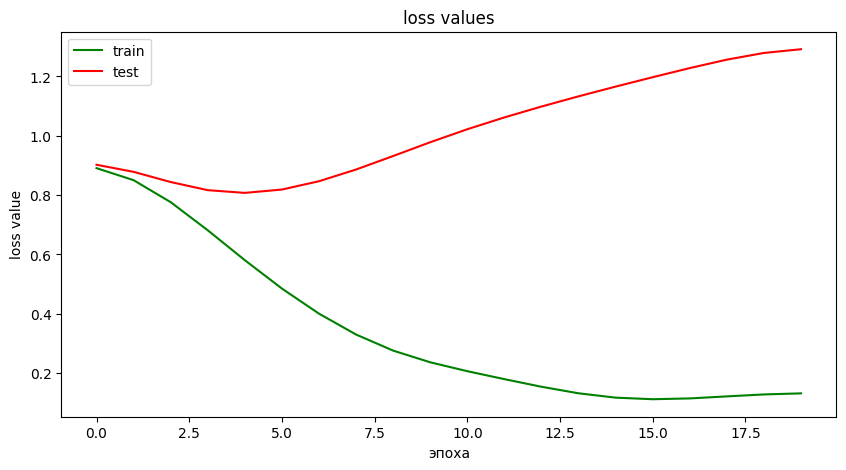

In [27]:
# строим графики - функции потерь

from scipy.ndimage.filters import gaussian_filter1d
fig = plt.figure(figsize=(10,5))

ax = fig.add_subplot(111)
ax.set(title = 'loss values',
       xlabel = 'эпоха',
       ylabel = 'loss value')
train_loss_smoothed = gaussian_filter1d(train_loss_history, sigma=2)
ax.plot(train_loss_smoothed, color='green',  label='train')

test_loss_smoothed = gaussian_filter1d(test_loss_history, sigma=2)
ax.plot(test_loss_smoothed, color='red',  label='test')
ax.legend()
plt.show()


C:\Users\kanze\AppData\Local\Temp\ipykernel_11352\2429959053.py:3: DeprecationWarning: Please import `gaussian_filter1d` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.filters import gaussian_filter1d


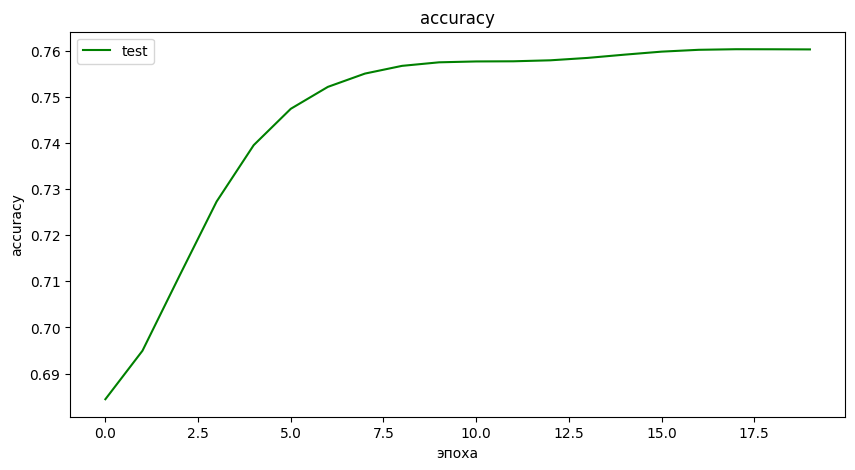

In [28]:
# График изменения accuracy на тестовых данных

from scipy.ndimage.filters import gaussian_filter1d
fig = plt.figure(figsize=(10,5))

ax = fig.add_subplot(111)
ax.set(title = 'accuracy',
       xlabel = 'эпоха',
       ylabel = 'accuracy')
test_accuracy_smoothed = gaussian_filter1d(test_accuracy_history, sigma=2)
ax.plot(test_accuracy_smoothed, color='green',  label='test')

ax.legend()
plt.show()

In [30]:
!pip install dill


[notice] A new release of pip is available: 23.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
# вот так сохраняют модель с помощью dill
import dill

with open("resnet.dill", "wb") as dill_file:
    dill.dump(resnet, dill_file)

In [29]:
# вот так сохраняют модель с помощью pickle
import pickle

with open("resnet.pickle", "wb") as pickle_file:
    pickle.dump(resnet, pickle_file)


torch.Size([3, 32, 32])


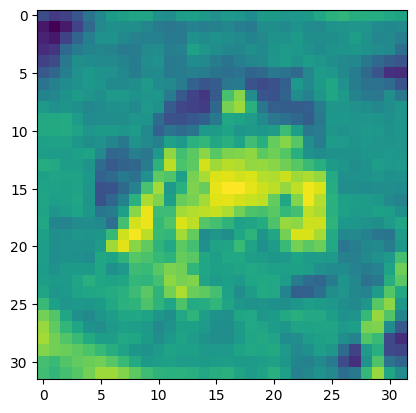

In [39]:
# сохраняем произвольное число из датасета (тензор) в файл
timg = X_train_tensor[0].to(device)
torch.save(timg,'resnet.pt')
print(timg.size())

# загружаем наше изображение
test_data = torch.load('resnet.pt', map_location=device)
test_data.shape
# смотрим, что за цифру считали
plt.imshow(test_data[0, :, :].cpu().numpy())
plt.show()

In [40]:
# переводим входной тензор-изображение в тензор нужного нам размера
t_data = torch.tensor([test_data.cpu().numpy()])  # Переносим на CPU перед преобразованием

C:\Users\kanze\AppData\Local\Temp\ipykernel_11352\870716471.py:2: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  t_data = torch.tensor([test_data.cpu().numpy()])  # Переносим на CPU перед преобразованием


In [41]:
#Проверяем
t_data.shape

torch.Size([1, 3, 32, 32])

In [44]:
# считываем модель, сохраненную в dill

ifile = open("resnet.dill", "rb")
resnet_model = dill.load(ifile)
ifile.close()

# смотрим, что пришло из dill файла
print(resnet_model)

ResNet18(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)


In [45]:
# смотрим тип модели
type(resnet_model)

__main__.ResNet18

In [46]:
resnet_model.to(device)
model_data2 = resnet_model.to(device)

In [47]:
# делаем предсказание
preds = resnet_model.forward(t_data)

In [48]:
print(preds)

tensor([[ 9.8930e-02, -1.9493e-02,  2.3245e+00,  3.2333e+00, -1.9550e+00,
         -4.1943e-01,  1.9878e+00, -8.1771e-01,  2.0221e+00, -8.7551e-01,
         -1.5490e+01, -1.5562e+01, -1.8052e+01, -1.6527e+01, -1.4107e+01,
         -1.6595e+01, -1.6382e+01, -1.7309e+01, -1.6144e+01, -1.7310e+01,
         -1.7132e+01, -1.8047e+01, -1.6441e+01, -1.5487e+01, -1.6401e+01,
         -1.5562e+01, -1.6536e+01, -1.5776e+01, -1.6259e+01, -1.6145e+01,
         -1.6600e+01, -1.5782e+01, -1.6300e+01, -1.5848e+01, -1.6973e+01,
         -1.7314e+01, -1.5524e+01, -1.5689e+01, -1.6583e+01, -1.7554e+01,
         -1.5484e+01, -1.6486e+01, -1.7282e+01, -1.6678e+01, -1.5999e+01,
         -1.6656e+01, -1.7934e+01, -1.6327e+01, -1.6733e+01, -1.7054e+01,
         -1.7631e+01, -1.6749e+01, -1.7182e+01, -1.5702e+01, -1.5745e+01,
         -1.7765e+01, -1.6676e+01, -1.6137e+01, -1.7105e+01, -1.5579e+01,
         -1.7019e+01, -1.7168e+01, -1.7239e+01, -1.6820e+01, -1.6247e+01,
         -1.5761e+01, -1.5192e+01, -1.

In [49]:
# выбираем максимальную вероятность, как результат предсказания.
# Не забывая отправить на cpu
prediction = np.argmax(preds.to('cpu').detach().numpy(),axis=1)

In [50]:
print(prediction)

[3]


Если преглядется, то прочитанный тензор чем-то похож на кота

| Метка | Описание       |
|-------|----------------|
| 0     | airplane       |
| 1     | automobile     |
| 2     | bird           |
| 3     | cat            |
| 4     | deer           |
| 5     | dog            |
| 6     | frog           |
| 7     | horse          |
| 8     | ship           |
| 9     | truck          |